In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [40]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.txt', sep = ';', header = None, names=['text', 'emotion'])

In [3]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [5]:
unique_emotions = df['emotion'].unique()
unique_emotions

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

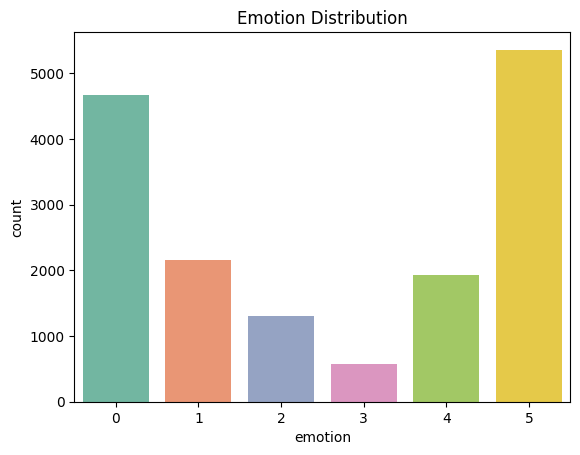

In [42]:
sns.countplot(x=df['emotion'], palette='Set2')
plt.title("Emotion Distribution")
plt.show()

In [6]:
emotion_numbers = {}

i=0
for emo in unique_emotions:
    emotion_numbers[emo] = i
    i+=1

df['emotion'] = df['emotion'].map(emotion_numbers)

In [7]:
df['text'] = df['text'].apply(lambda x: x.lower())

In [8]:
# remove punctuations.
import string 
def remove_punctuation(txt):
    return txt.translate(str.maketrans('', '', string.punctuation))

# Argument 1: Characters to be replaced.
# Argument 2: Characters to replace them with.
# Argument 3: Characters to be deleted.

In [9]:
df['text'] = df['text'].apply(remove_punctuation)

In [10]:
# remove numbers.
def remove_numbers(txt):
    new_n = ""
    for i in txt:
        if not i.isdigit():
            new_n += i
    return new_n 

df['text'] = df['text'].apply(remove_numbers)

In [11]:
# remove urls/links
def remove_links(txt):
    words = txt.split()
    clean_words = []
    for word in words:
        if not (word.startswith('http') or word.startswith('www')):
            clean_words.append(word)
    return " ".join(clean_words)

df['text'] = df['text'].apply(remove_links)

In [12]:
# remove html tags.
# this data was not scraped from anywhere. it was taken from kaggle, so wont have any html tags.

def is_html(txt):
    words = txt.split() 
    html = []
    for word in words:
        if word.startswith('<'):
            html.append(word)
    return html
df['text'].apply(is_html).value_counts()   # no html tags.

text
[]    16000
Name: count, dtype: int64

In [13]:
# remove emojis and special characters.

def remove_emojis(txt):
    new_t = ""
    for i in txt:
        if i.isascii():
            new_t += i
    return new_t

df['text'] = df['text'].apply(remove_emojis)

In [14]:
# remove stopwords.

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Mrunmayee
[nltk_data]     Potdar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Mrunmayee
[nltk_data]     Potdar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [16]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Mrunmayee
[nltk_data]     Potdar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
def remove_stopwords(txt):
    words = word_tokenize(txt)
    cleaned_txt = []
    for i in words:
        if not i in stop_words:
            cleaned_txt.append(i)
    
    return ' '.join(cleaned_txt)

df['text'] = df['text'].apply(remove_stopwords)

In [18]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.2, random_state = 42)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [21]:
bow_vec = CountVectorizer()
X_train_bow = bow_vec.fit_transform(X_train)
X_train_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 115836 stored elements and shape (12800, 13356)>

In [22]:
X_test_bow = bow_vec.transform(X_test)
X_test_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 26895 stored elements and shape (3200, 13356)>

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
nb_model = MultinomialNB()

In [25]:
nb_model.fit(X_train_bow, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
nb_pred = nb_model.predict(X_test_bow)

In [27]:
accuracy_score(y_test, nb_pred)

0.7684375

In [28]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.75      0.95      0.84       946
           1       0.89      0.64      0.74       427
           2       0.93      0.26      0.41       296
           3       1.00      0.05      0.10       113
           4       0.85      0.57      0.68       397
           5       0.73      0.96      0.83      1021

    accuracy                           0.77      3200
   macro avg       0.86      0.57      0.60      3200
weighted avg       0.80      0.77      0.74      3200



<Axes: >

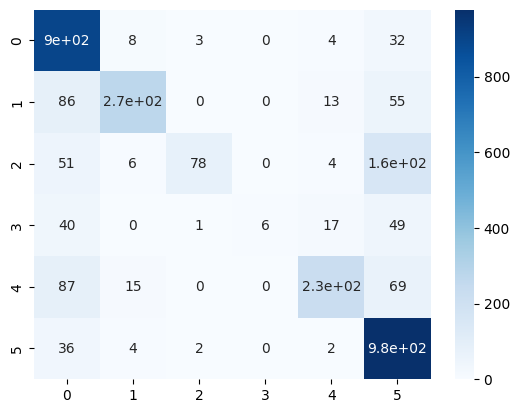

In [29]:
cm = confusion_matrix(y_test, nb_pred)
import seaborn as sns
sns.heatmap(cm, annot=True, cmap = 'Blues')

In [30]:
tfidf_vec = TfidfVectorizer()
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 115836 stored elements and shape (12800, 13356)>

In [31]:
X_test_tfidf = tfidf_vec.transform(X_test)
X_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 26895 stored elements and shape (3200, 13356)>

In [32]:
nb2 = MultinomialNB()

In [33]:
nb2.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [34]:
y_pred = nb2.predict(X_test_tfidf)

In [35]:
accuracy_score(y_test, y_pred)

0.66125

In [36]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(max_iter = 1000)

In [37]:
logistic.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
log_pred = logistic.predict(X_test_tfidf)

In [39]:
accuracy_score(y_test, log_pred)

0.860625

emotion detection relies on important keywords. tfidf is a better choice.

In [44]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.891875


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_tfidf, y_train)

rf_pred = rf.predict(X_test_tfidf)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8803125


In [46]:
print("NB + BOW:", accuracy_score(y_test, nb_pred))
print("NB + TFIDF:", accuracy_score(y_test, y_pred))
print("Logistic + TFIDF:", accuracy_score(y_test, log_pred))
print("Linear SVM + TFIDF:", accuracy_score(y_test, svm_pred))
print("Random Forest + TFIDF:",accuracy_score(y_test, rf_pred))

NB + BOW: 0.7684375
NB + TFIDF: 0.66125
Logistic + TFIDF: 0.860625
Linear SVM + TFIDF: 0.891875
Random Forest + TFIDF: 0.8803125


linear svm + tfidf worked the best.

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       946
           1       0.89      0.88      0.89       427
           2       0.83      0.74      0.78       296
           3       0.87      0.70      0.77       113
           4       0.87      0.85      0.86       397
           5       0.89      0.94      0.91      1021

    accuracy                           0.89      3200
   macro avg       0.88      0.84      0.86      3200
weighted avg       0.89      0.89      0.89      3200



<Axes: >

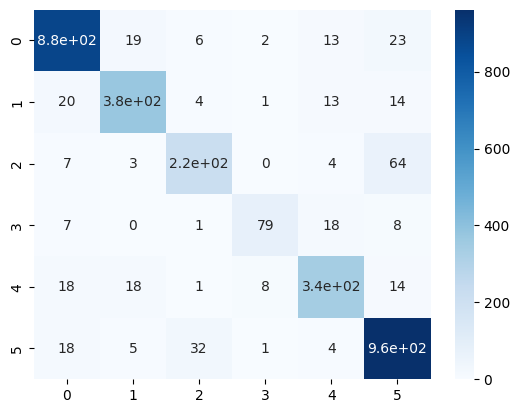

In [47]:
print(classification_report(y_test, svm_pred))
cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm, annot=True, cmap='Blues')

model tuning, improving accuracy.

In [49]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

# sublinear_tf=True ---->
# Instead of raw count, TF becomes: 1 + log(tf)
# repeated words don't dominate the sentence representation.

In [51]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
svc_tuned = LinearSVC()

param_grid = {
    'C': [0.1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5], 
    "loss":["hinge","squared_hinge"],
    "class_weight":[None,"balanced"]
}

grid = GridSearchCV(
    svc_tuned, 
    param_grid, 
    cv=5, 
    scoring="accuracy"
)

grid.fit(X_train_tfidf, y_train)

print("best parameters: ", grid.best_params_)
print("best score: ", grid.best_score_)

best parameters:  {'C': 1, 'class_weight': 'balanced', 'loss': 'hinge'}
best score:  0.904921875


accuracy improved!!

In [55]:
print("NB + BOW:", accuracy_score(y_test, nb_pred))
print("NB + TFIDF:", accuracy_score(y_test, y_pred))
print("Logistic + TFIDF:", accuracy_score(y_test, log_pred))
print("Linear SVM + TFIDF:", accuracy_score(y_test, svm_pred))
print("Random Forest + TFIDF:",accuracy_score(y_test, rf_pred))
print("The best model ---> Linear SVM + TFIDF. Tuning it to improve performance")
print("After tuning Linear SVM + TFIDF:", grid.best_score_)

NB + BOW: 0.7684375
NB + TFIDF: 0.66125
Logistic + TFIDF: 0.860625
Linear SVM + TFIDF: 0.891875
Random Forest + TFIDF: 0.8803125
The best model ---> Linear SVM + TFIDF. Tuning it to improve performance
After tuning Linear SVM + TFIDF: 0.904921875


In [58]:
import pickle 
best_model = grid.best_estimator_
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))